# Nyquist–Shannon Sampling with Tokyo Weather

## Dataset

Source: Meteostat Hourly API

Location: Tokyo Station area (≈ 35.6812, 139.7671) — timezone Asia/Tokyo

Cadence: Hourly (uniform sampling)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Hourly


plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

### Data

In [2]:
# Tokyo Station vicinity
tokyo = Point(35.6812, 139.7671)
start = datetime(2024, 1, 1)
end = datetime(2024, 3, 31)


# 1) Fetch WITHOUT tz argument
df = Hourly(tokyo, start, end).fetch()


# 2) Make sure the index is in Asia/Tokyo
# - If tz-aware, convert to Asia/Tokyo.
# - If tz-naive, assume UTC (Meteostat default) then convert.
if df.index.tz is None:
    df = df.tz_localize('UTC').tz_convert('Asia/Tokyo')
else:
    df = df.tz_convert('Asia/Tokyo')


# 3) Keep common fields if present
cols = [c for c in ['temp','wspd','pres'] if c in df.columns]
if cols:
    df = df[cols]


# 4) Deduplicate any accidental duplicates
df = df[~df.index.duplicated(keep='first')]


print(df.index.tz) # should show Asia/Tokyo
print(df.head())

Asia/Tokyo
                           temp  wspd    pres
time                                         
2024-01-01 09:00:00+09:00   9.7  20.5  1018.6
2024-01-01 10:00:00+09:00  10.6  29.5  1019.3
2024-01-01 11:00:00+09:00  11.5  20.5  1019.2
2024-01-01 12:00:00+09:00  11.6  18.4  1019.2
2024-01-01 13:00:00+09:00  11.8  20.5  1019.6


## Day 1

In [3]:
def estimate_bandwidth(signal: pd.Series, fs_per_hour: float = 1.0, energy_quantile: float = 0.95):
    x = signal.dropna().values
    x = x - np.mean(x)
    N = len(x)
    if N < 16:
        raise ValueError('Need >= 16 samples for spectrum.')
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / N
    f = np.fft.rfftfreq(N, d=1.0/fs_per_hour) # cycles/hour
    c = np.cumsum(P); c = c / c[-1]
    idx = np.searchsorted(c, energy_quantile)
    B = f[min(idx, len(f)-1)]
    return float(B), f, P

In [4]:
sig_name = 'temp' if 'temp' in df.columns else ('wspd' if 'wspd' in df.columns else df.columns[0])
sig = df[sig_name]
fs = 1.0 # hourly sampling -> 1 sample/hour
B, f, P = estimate_bandwidth(sig, fs_per_hour=fs, energy_quantile=0.95)
nyquist_rate = 2 * B
nyquist_freq = B
print(f"Signal: {sig_name}")
print(f"Estimated B: {B:.4f} cycles/hour")
print(f"Nyquist frequency f_N: {nyquist_freq:.4f} cycles/hour")
print(f"Nyquist rate >= 2B: {nyquist_rate:.4f} samples/hour")

Signal: temp
Estimated B: 0.0764 cycles/hour
Nyquist frequency f_N: 0.0764 cycles/hour
Nyquist rate >= 2B: 0.1527 samples/hour


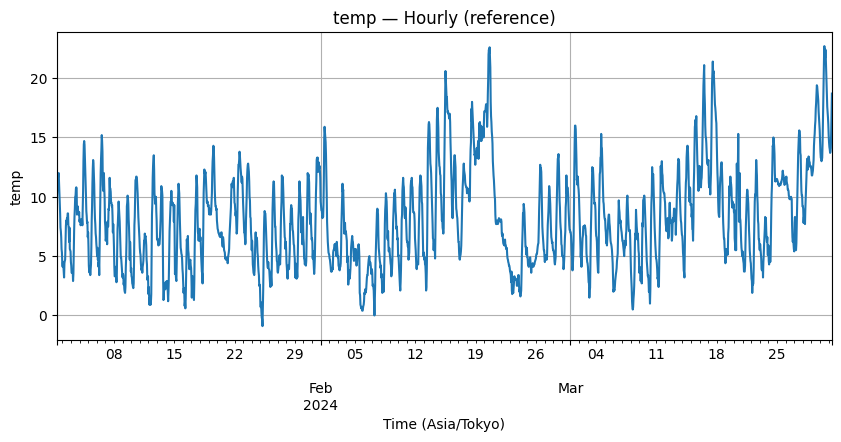

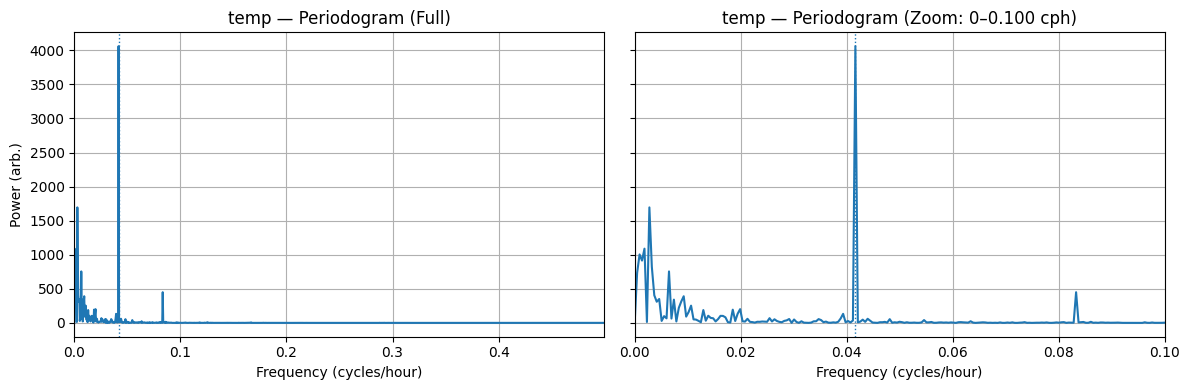

In [5]:
# Baseline hourly series
ax = sig.plot(); ax.set_title(f"{sig_name} — Hourly (reference)")
ax.set_xlabel("Time (Asia/Tokyo)"); ax.set_ylabel(sig_name)
plt.show()

# Periodogram (one‑sided) — full vs zoomed subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Full spectrum
ax = axes[0]
ax.plot(f, P)
ax.set_xlim(0, f.max())
ax.set_xlabel("Frequency (cycles/hour)"); ax.set_ylabel("Power (arb.)")
ax.set_title(f"{sig_name} — Periodogram (Full)")
# Mark diurnal freq ~ 1/24 cph for context
ax.axvline(1/24, linestyle=':', linewidth=1)

# Zoomed low-frequency band (captures diurnal & sub‑daily)
zoom_max = min(0.1, float(f.max()))  # up to 0.25 cph (~4 hours period)
ax = axes[1]
ax.plot(f, P)
ax.set_xlim(0, zoom_max)
ax.set_xlabel("Frequency (cycles/hour)"); ax.set_ylabel("")
ax.set_title(f"{sig_name} — Periodogram (Zoom: 0–{zoom_max:.3f} cph)")
ax.axvline(1/24, linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

## Day 2

### Objective

Show what happens when you downsample the hourly series to coarser cadences (e.g., 6‑hour) with and without an anti‑aliasing low‑pass.

### Method

- Reference: hourly series (fs = 1 cph).

- Target cadences: 3h, 6h, 12h, 24h.

- No prefilter: plain resample/mean.

- With prefilter: moving‑average window roughly matching the cadence (simple low‑pass).

In [6]:
# Use lowercase 'h' to avoid pandas FutureWarning
cadences = ['3h','6h','12h','24h']

def moving_average(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window, min_periods=1, center=True).mean()

# Build a dict of downsampled series for *all* cadences, with & without prefilter
downsampled = {}
for c in cadences:
    # No prefilter (boxcar via resample mean)
    z = sig.resample(c).mean()
    downsampled[(c,'no_filter')] = z
    # With simple anti‑alias (moving average) prior to decimation
    hours = int(pd.to_timedelta(c).total_seconds() // 3600)
    filt = moving_average(sig, window=max(hours,1))
    z_filt = filt.resample(c).mean()
    downsampled[(c,'with_ma_filter')] = z_filt

# Make a consistent 7‑day zoom window
zoom_end = sig.index.max()
zoom_start = zoom_end - pd.Timedelta(days=7)

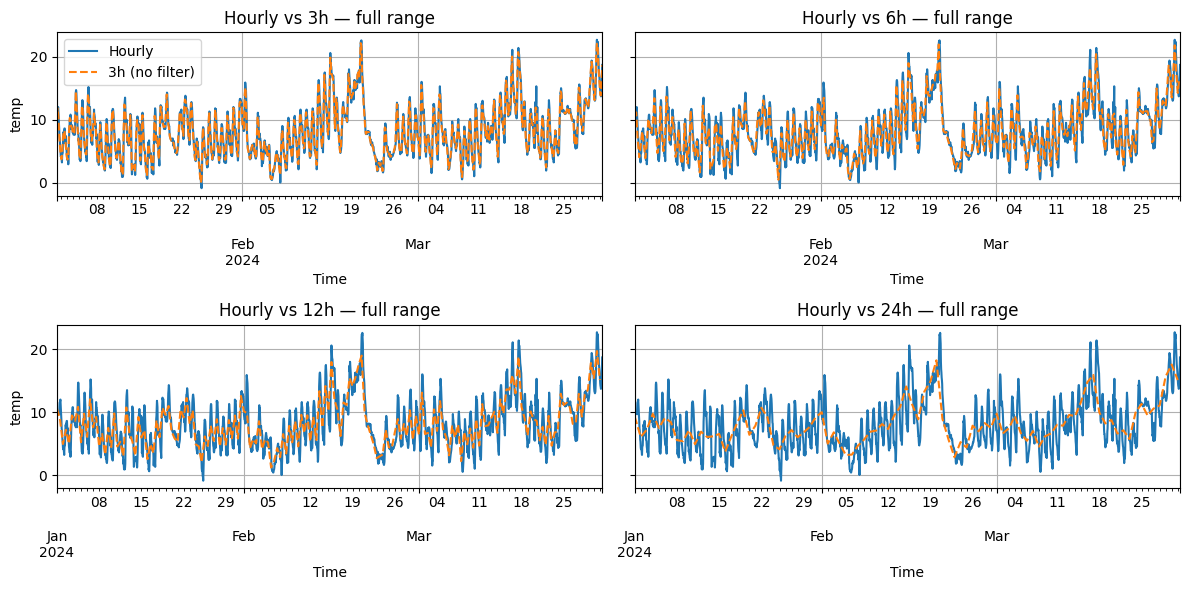

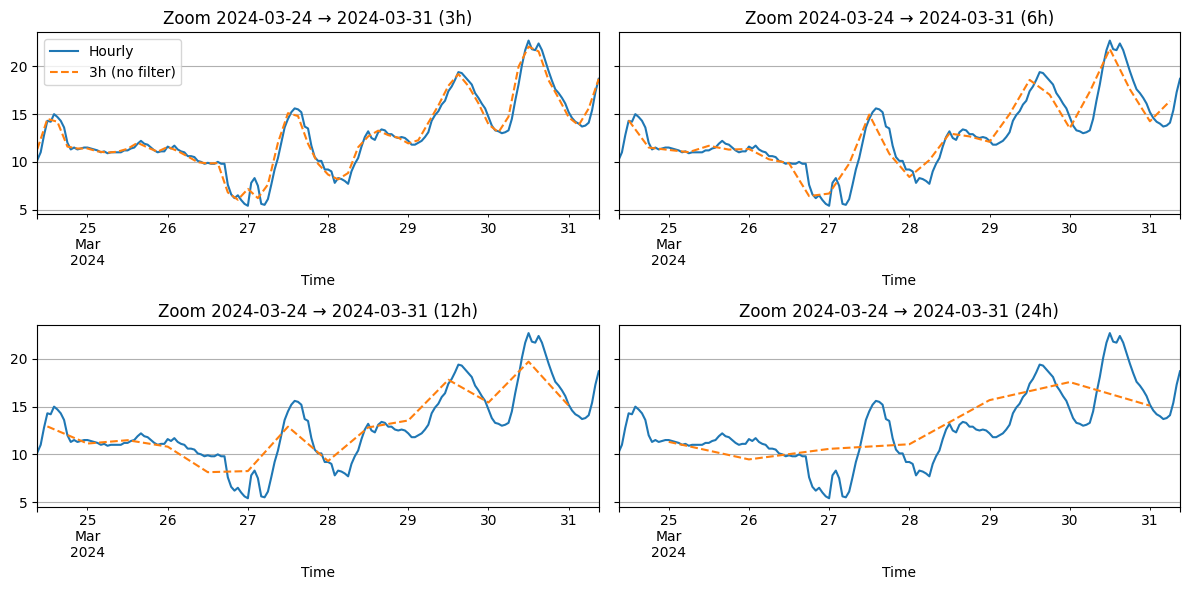

In [7]:
# Small multiples: Hourly vs each cadence (NO PREFILTER)
cols = 2
rows = int(np.ceil(len(cadences)/cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows), sharey=True)
axes = axes.ravel()
for i, c in enumerate(cadences):
    ax = axes[i]
    sig.plot(ax=ax, label='Hourly')
    downsampled[(c,'no_filter')].plot(ax=ax, style='--', label=f'{c} (no filter)')
    ax.set_title(f"Hourly vs {c} — full range")
    ax.set_xlabel("Time"); ax.set_ylabel(sig_name)
    if i == 0: ax.legend()
# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

# Small multiples: Hourly vs each cadence (NO PREFILTER) — ZOOM
fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows), sharey=True)
axes = axes.ravel()
for i, c in enumerate(cadences):
    ax = axes[i]
    sig.loc[zoom_start:zoom_end].plot(ax=ax, label='Hourly')
    downsampled[(c,'no_filter')].loc[zoom_start:zoom_end].plot(ax=ax, style='--', label=f'{c} (no filter)')
    ax.set_title(f"Zoom {zoom_start.date()} → {zoom_end.date()} ({c})")
    ax.set_xlabel("Time"); ax.set_ylabel("")
    if i == 0: ax.legend()
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

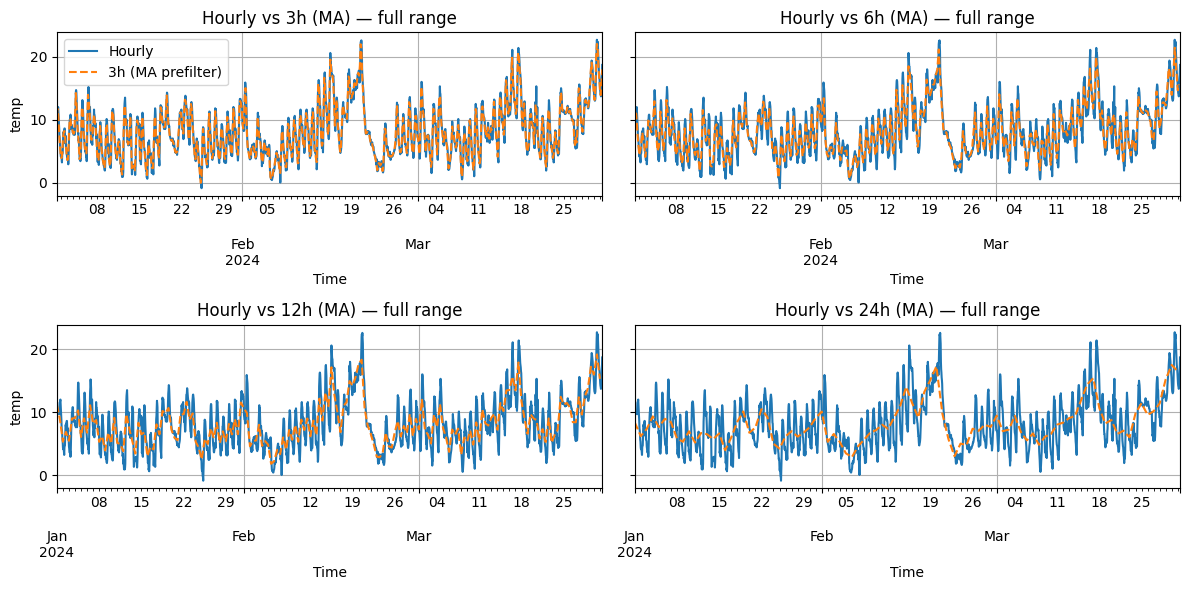

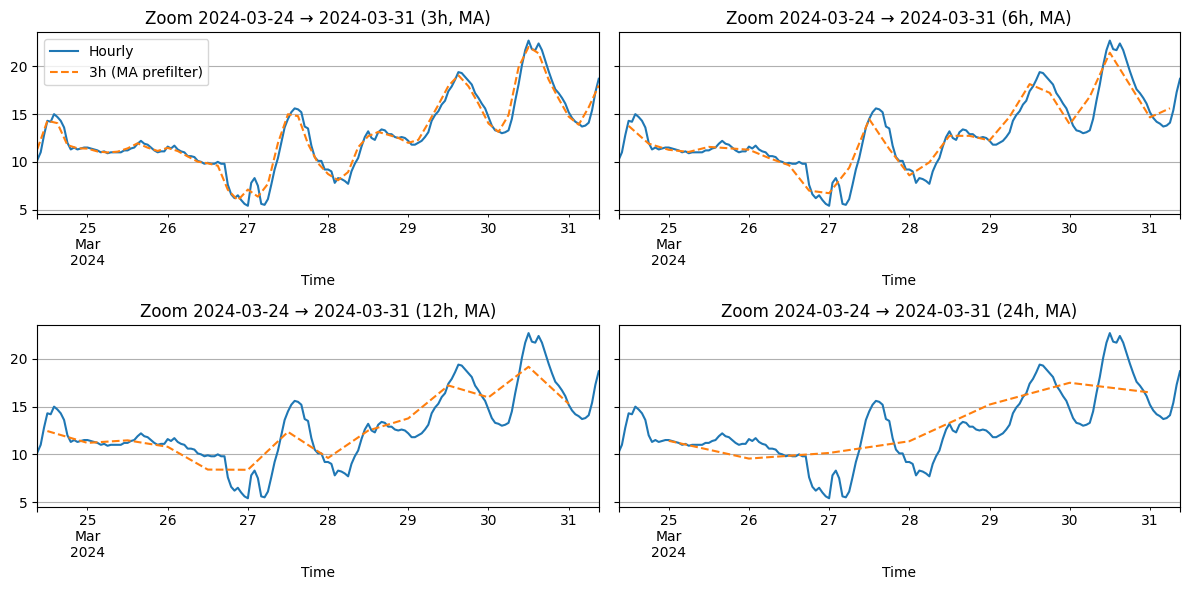

In [8]:
# Small multiples: Hourly vs each cadence (WITH MA PREFILTER) — full & zoom
fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows), sharey=True)
axes = axes.ravel()
for i, c in enumerate(cadences):
    ax = axes[i]
    sig.plot(ax=ax, label='Hourly')
    downsampled[(c,'with_ma_filter')].plot(ax=ax, style='--', label=f'{c} (MA prefilter)')
    ax.set_title(f"Hourly vs {c} (MA) — full range")
    ax.set_xlabel("Time"); ax.set_ylabel(sig_name)
    if i == 0: ax.legend()
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows), sharey=True)
axes = axes.ravel()
for i, c in enumerate(cadences):
    ax = axes[i]
    sig.loc[zoom_start:zoom_end].plot(ax=ax, label='Hourly')
    downsampled[(c,'with_ma_filter')].loc[zoom_start:zoom_end].plot(ax=ax, style='--', label=f'{c} (MA prefilter)')
    ax.set_title(f"Zoom {zoom_start.date()} → {zoom_end.date()} ({c}, MA)")
    ax.set_xlabel("Time"); ax.set_ylabel("")
    if i == 0: ax.legend()
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [9]:
def periodogram(series: pd.Series, fs_per_hour: float):
    x = series.dropna().values
    x = x - np.mean(x)
    N = len(x)
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / max(N,1)
    f = np.fft.rfftfreq(max(N,1), d=1.0/fs_per_hour)
    return f, P

# Compute spectra for hourly and for each cadence (no filter + MA)
F = {}
PWR = {}
F[('1h','ref')], PWR[('1h','ref')] = periodogram(sig, fs_per_hour=1.0)
for c in cadences:
    fs_c = 1.0 / int(pd.to_timedelta(c).total_seconds() // 3600)
    # No filter
    f_c, P_c = periodogram(downsampled[(c,'no_filter')].interpolate().dropna(), fs_per_hour=fs_c)
    F[(c,'no_filter')], PWR[(c,'no_filter')] = f_c, P_c
    # With MA prefilter
    f_cf, P_cf = periodogram(downsampled[(c,'with_ma_filter')].interpolate().dropna(), fs_per_hour=fs_c)
    F[(c,'with_ma_filter')], PWR[(c,'with_ma_filter')] = f_cf, P_cf

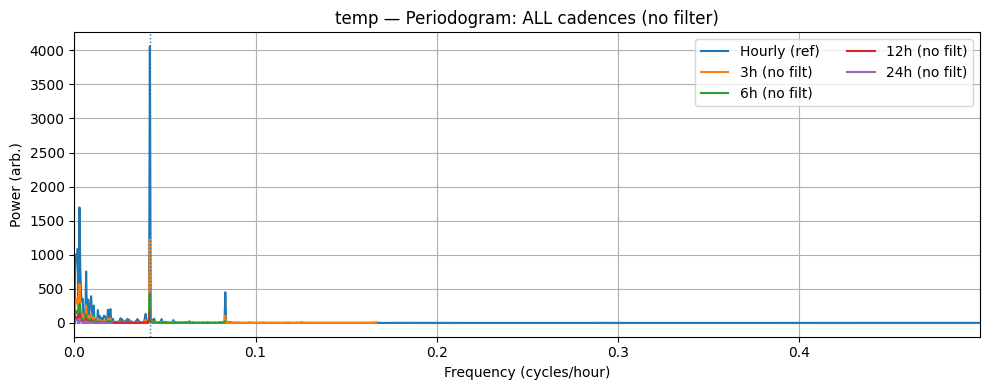

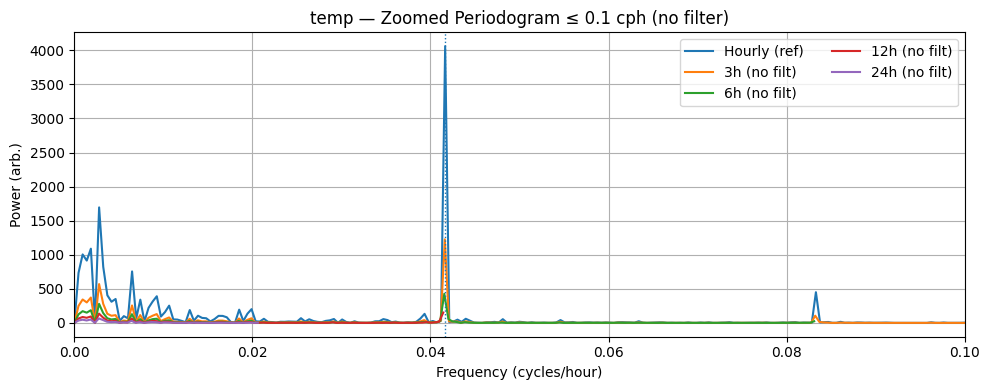

In [10]:
# Overlay ALL cadences against hourly — FULL spectrum (no filter)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(F[('1h','ref')], PWR[('1h','ref')], label='Hourly (ref)')
for c in cadences:
    ax.plot(F[(c,'no_filter')], PWR[(c,'no_filter')], label=f'{c} (no filt)')
ax.set_xlim(0, max(F[('1h','ref')].max(), max(F[(c,'no_filter')].max() for c in cadences)))
ax.set_xlabel('Frequency (cycles/hour)'); ax.set_ylabel('Power (arb.)')
ax.set_title(f"{sig_name} — Periodogram: ALL cadences (no filter)")
ax.axvline(1/24, linestyle=':', linewidth=1)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

# Overlay ALL cadences — ZOOM (no filter)
zoom_max = 0.1  # focus on <= 0.1 cph (~10h period and longer)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(F[('1h','ref')], PWR[('1h','ref')], label='Hourly (ref)')
for c in cadences:
    ax.plot(F[(c,'no_filter')], PWR[(c,'no_filter')], label=f'{c} (no filt)')
ax.set_xlim(0, zoom_max)
ax.set_xlabel('Frequency (cycles/hour)'); ax.set_ylabel('Power (arb.)')
ax.set_title(f"{sig_name} — Zoomed Periodogram ≤ {zoom_max} cph (no filter)")
ax.axvline(1/24, linestyle=':', linewidth=1)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

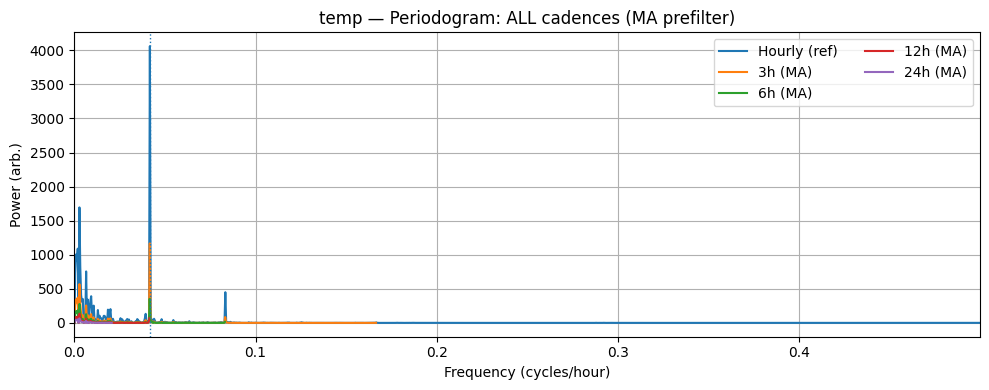

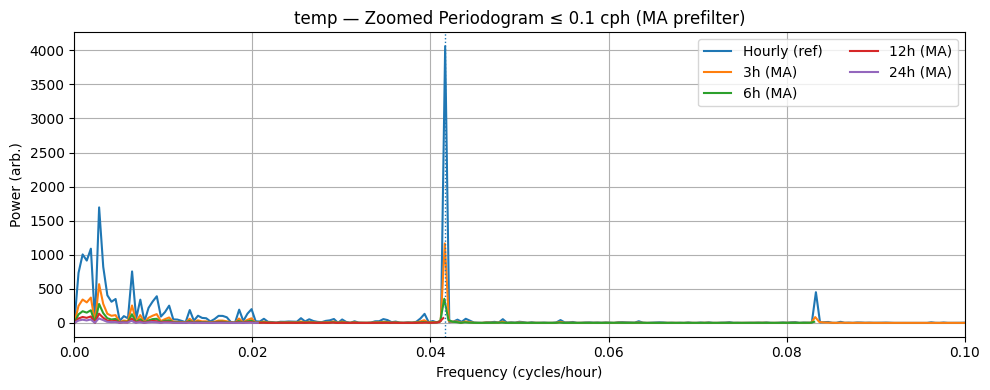

In [11]:
# Overlay ALL cadences — FULL spectrum (MA prefilter)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(F[('1h','ref')], PWR[('1h','ref')], label='Hourly (ref)')
for c in cadences:
    ax.plot(F[(c,'with_ma_filter')], PWR[(c,'with_ma_filter')], label=f'{c} (MA)')
ax.set_xlim(0, max(F[('1h','ref')].max(), max(F[(c,'with_ma_filter')].max() for c in cadences)))
ax.set_xlabel('Frequency (cycles/hour)'); ax.set_ylabel('Power (arb.)')
ax.set_title(f"{sig_name} — Periodogram: ALL cadences (MA prefilter)")
ax.axvline(1/24, linestyle=':', linewidth=1)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

# Overlay ALL cadences — ZOOM (MA prefilter)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(F[('1h','ref')], PWR[('1h','ref')], label='Hourly (ref)')
for c in cadences:
    ax.plot(F[(c,'with_ma_filter')], PWR[(c,'with_ma_filter')], label=f'{c} (MA)')
ax.set_xlim(0, zoom_max)
ax.set_xlabel('Frequency (cycles/hour)'); ax.set_ylabel('Power (arb.)')
ax.set_title(f"{sig_name} — Zoomed Periodogram ≤ {zoom_max} cph (MA prefilter)")
ax.axvline(1/24, linestyle=':', linewidth=1)
ax.legend(ncol=2)
plt.tight_layout(); plt.show()